In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


import os
os.path.exists(r"C:\Users\jarup\OneDrive\Desktop\Project file\crop_yield.csv")

True

In [2]:
df=pd.read_csv(r"C:\Users\jarup\OneDrive\Desktop\Project file\crop_yield.csv")

In [7]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [9]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [19]:
df.duplicated().sum()

0

In [21]:
len(df["State"].unique())

30

In [25]:
len(df["Season"].unique())

6

In [27]:
len(df["Crop"].unique())

55

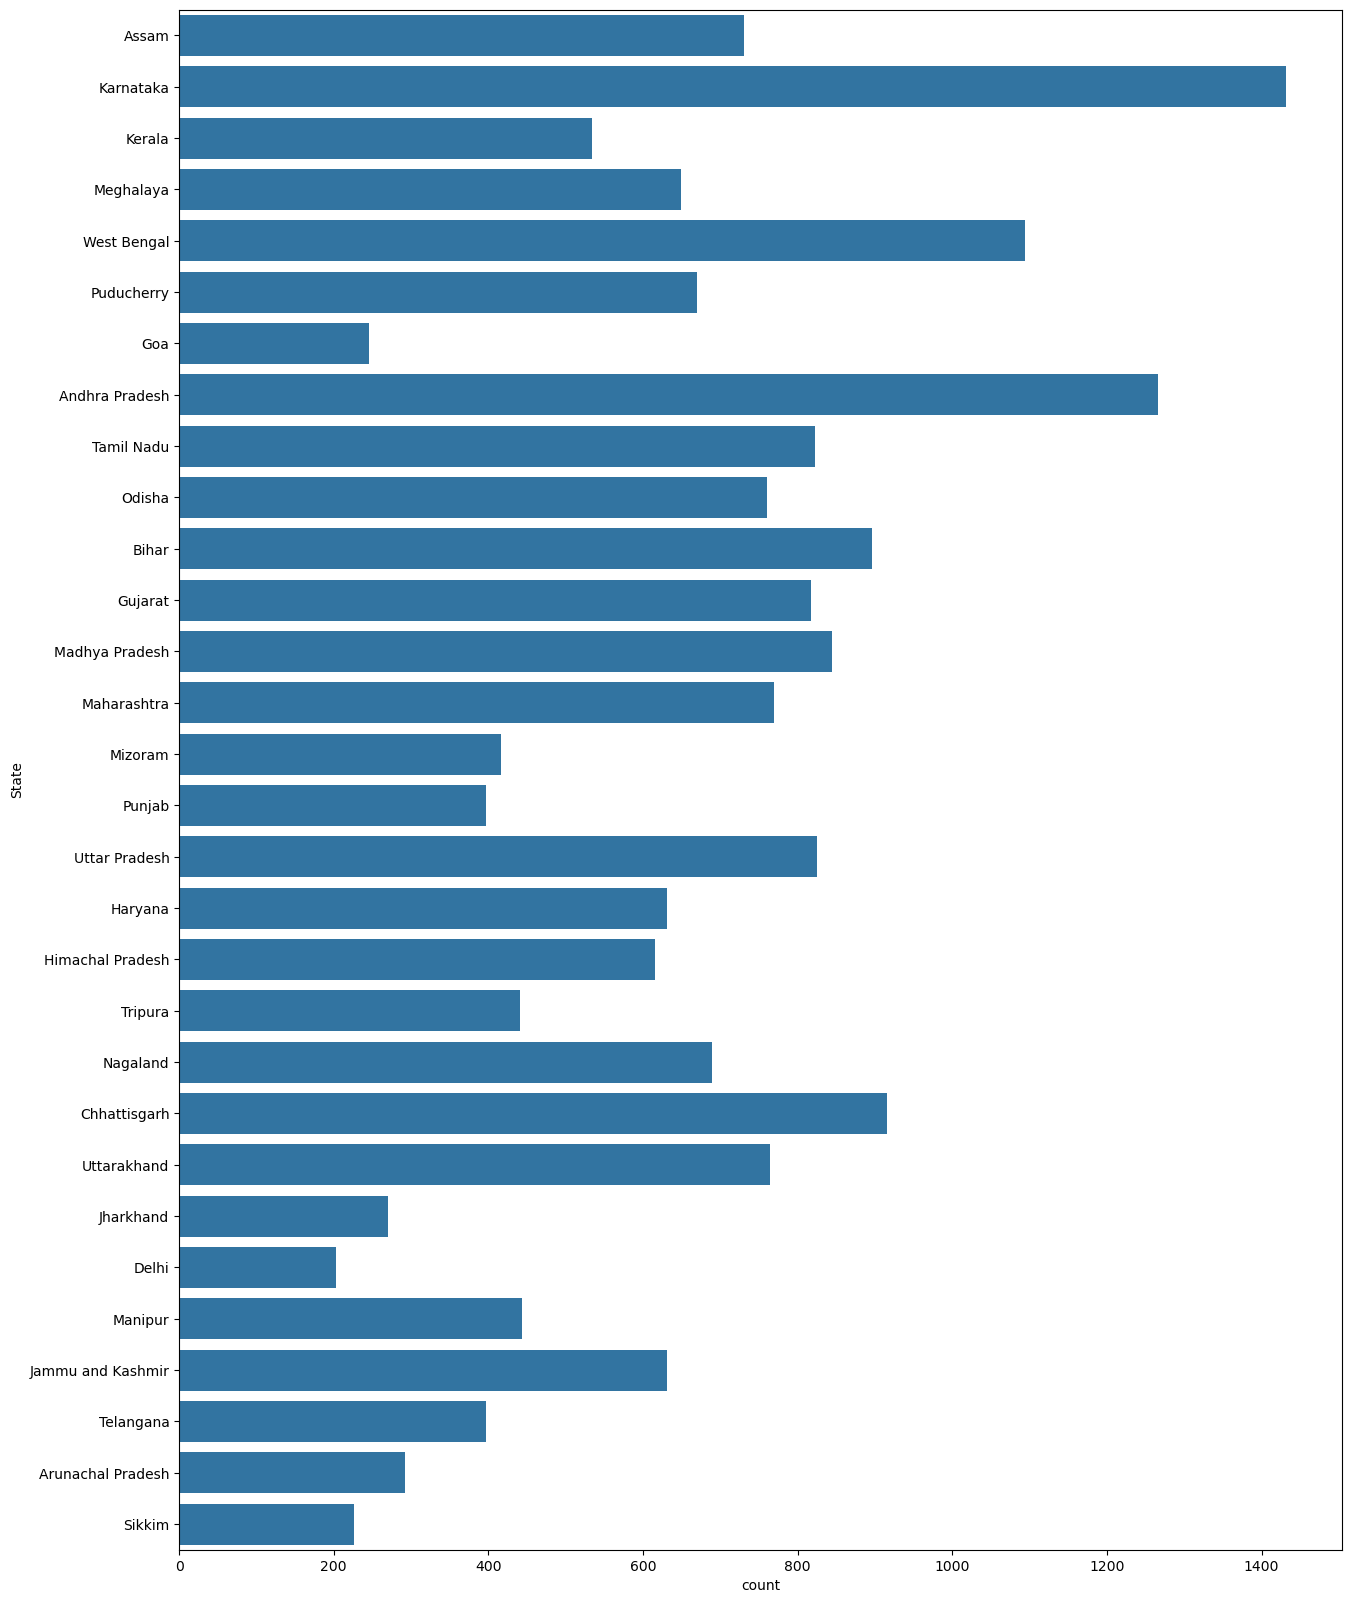

In [29]:
plt.figure(figsize=(15,20))
sns.countplot(y=df['State'])
plt.show()

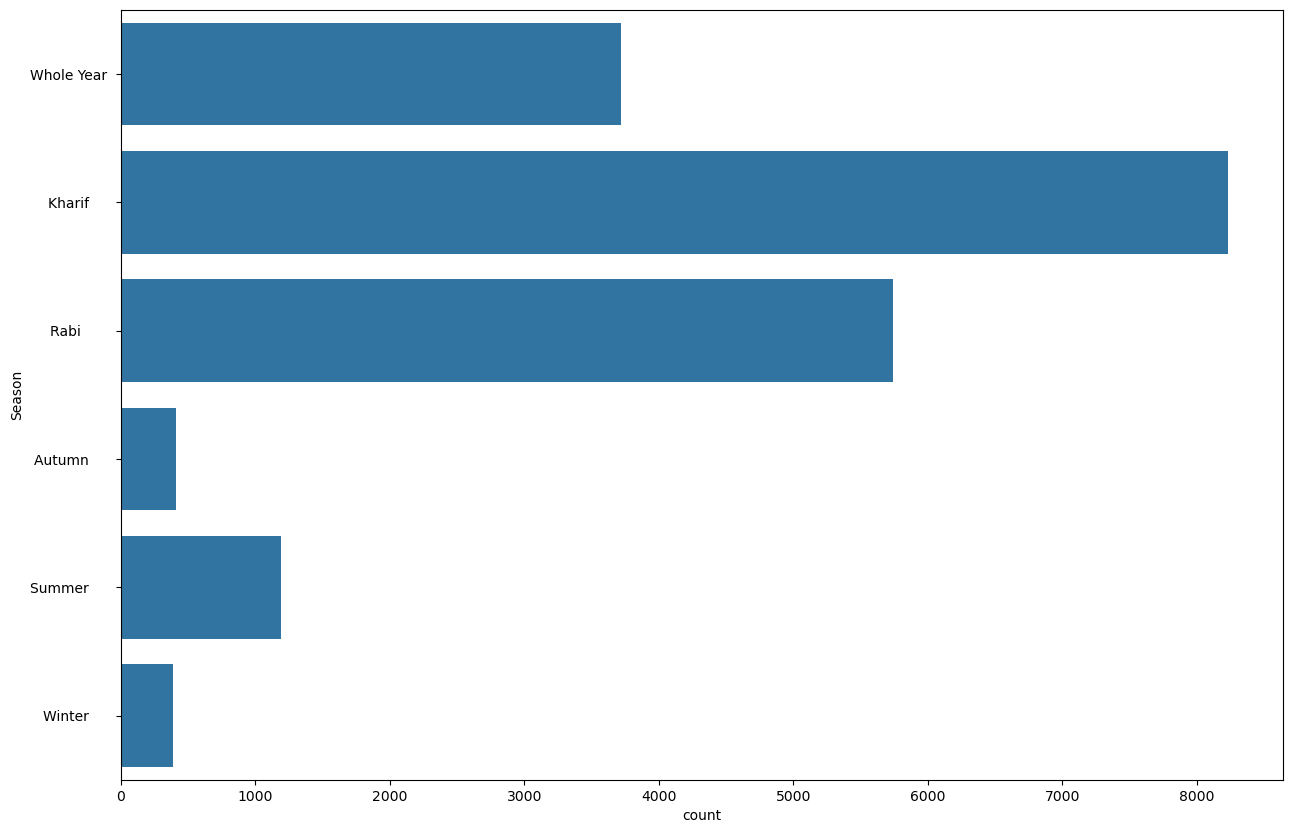

In [33]:
plt.figure(figsize=(15,10))
sns.countplot(y=df['Season'])
plt.show()

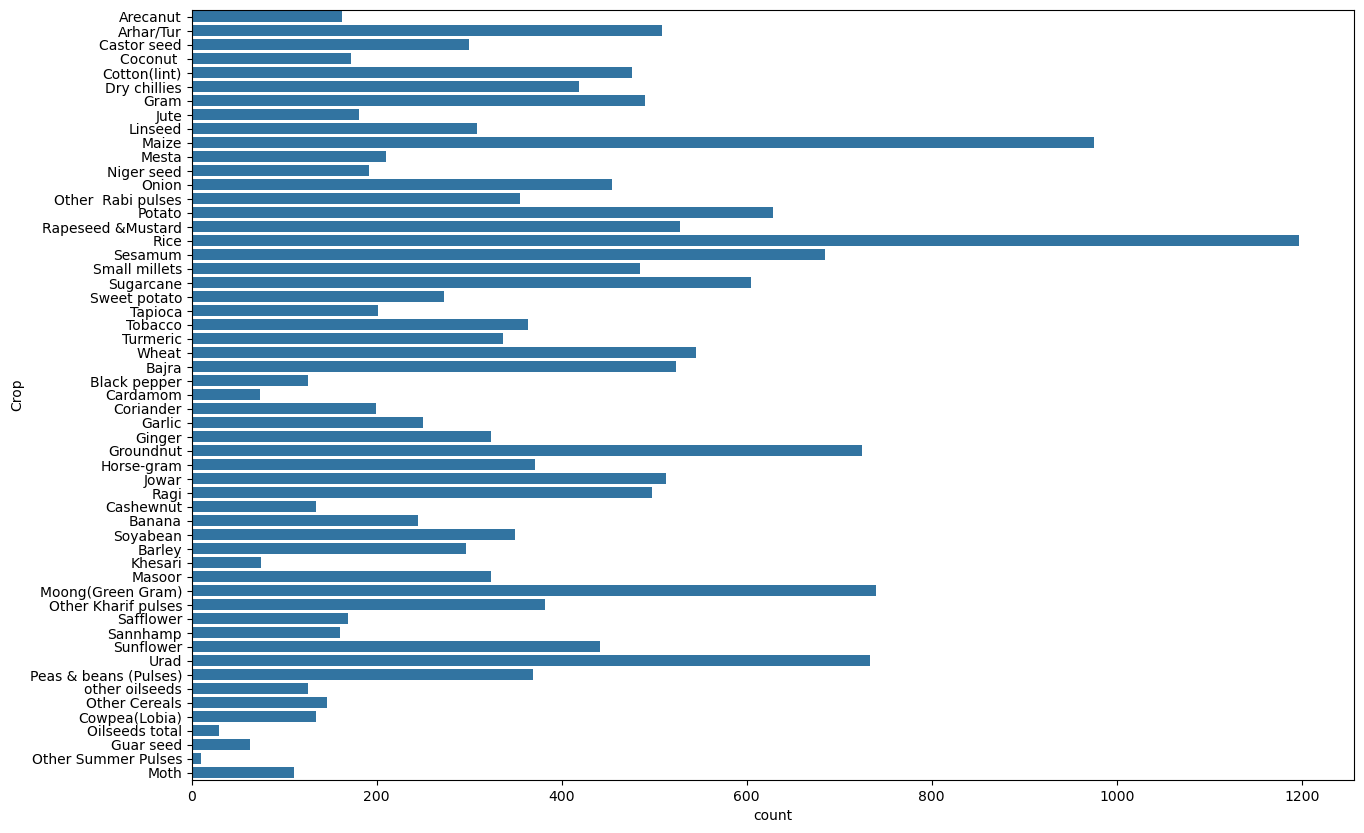

In [41]:
plt.figure(figsize=(15,10))
sns.countplot(y=df['Crop'])
plt.show()

In [35]:
state=df["State"].unique()
yield_per_state=[]
for states in state :
    yield_per_state.append(df[df['State']==states]['Yield'].sum())

In [37]:
df['Yield'].sum()

1574214.485762277

In [45]:
crops=df["Crop"].unique()
yield_per_crop=[]
for crop in crops :
    yield_per_crop.append(df[df['Crop']==states]['Yield'].sum())

In [47]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [49]:
x=df.drop('Yield',axis=1)
y=df['Yield']

In [56]:
x.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09


In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.3)

In [60]:
X_train.shape,X_test.shape

((13782, 9), (5907, 9))

In [66]:
X_train

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
9468,Moong(Green Gram),2005,Kharif,Madhya Pradesh,75291.00,22940,1032.700000,9.028897e+06,15811.1100
14111,Urad,2014,Summer,Uttarakhand,57.00,32,1287.400000,8.604720e+03,18.8100
13022,Rice,2012,Autumn,West Bengal,205082.00,471150,1566.000000,3.092637e+07,63575.4200
6181,Jowar,1997,Kharif,Bihar,3129.00,2690,1303.700000,2.977869e+05,969.9900
7742,Rice,2001,Rabi,Nagaland,1500.00,2000,1532.000000,1.531950e+05,390.0000
...,...,...,...,...,...,...,...,...,...
10955,Gram,2008,Rabi,Jharkhand,17036.59,12398,1295.200000,2.436914e+06,1533.2931
17289,Moong(Green Gram),2019,Rabi,West Bengal,1900.00,1497,1733.400000,3.263440e+05,703.0000
5192,Maize,2017,Kharif,Assam,31537.00,98783,2098.563636,4.965185e+06,11984.0600
12172,Potato,2011,Rabi,Himachal Pradesh,3431.00,23799,1108.300000,5.747611e+05,1132.2300


In [88]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
ohe = OneHotEncoder(drop='first',handle_unknown='ignore')
scale = StandardScaler()

preprocesser = ColumnTransformer(
        transformers = [
            ('StandardScale', scale, [1,4,5,6,7,8]),
            ('OHE', ohe, [0,2,3]),
        ],
        remainder='passthrough'
)

In [90]:
X_train_dummy = preprocesser.fit_transform(X_train)
X_test_dummy = preprocesser.transform(X_test)

In [92]:
preprocesser.get_feature_names_out(df.columns[:-1])

array(['StandardScale__Crop_Year', 'StandardScale__Area',
       'StandardScale__Production', 'StandardScale__Annual_Rainfall',
       'StandardScale__Fertilizer', 'StandardScale__Pesticide',
       'OHE__Crop_Arhar/Tur', 'OHE__Crop_Bajra', 'OHE__Crop_Banana',
       'OHE__Crop_Barley', 'OHE__Crop_Black pepper', 'OHE__Crop_Cardamom',
       'OHE__Crop_Cashewnut', 'OHE__Crop_Castor seed',
       'OHE__Crop_Coconut ', 'OHE__Crop_Coriander',
       'OHE__Crop_Cotton(lint)', 'OHE__Crop_Cowpea(Lobia)',
       'OHE__Crop_Dry chillies', 'OHE__Crop_Garlic', 'OHE__Crop_Ginger',
       'OHE__Crop_Gram', 'OHE__Crop_Groundnut', 'OHE__Crop_Guar seed',
       'OHE__Crop_Horse-gram', 'OHE__Crop_Jowar', 'OHE__Crop_Jute',
       'OHE__Crop_Khesari', 'OHE__Crop_Linseed', 'OHE__Crop_Maize',
       'OHE__Crop_Masoor', 'OHE__Crop_Mesta',
       'OHE__Crop_Moong(Green Gram)', 'OHE__Crop_Moth',
       'OHE__Crop_Niger seed', 'OHE__Crop_Oilseeds total',
       'OHE__Crop_Onion', 'OHE__Crop_Other  Rabi pulses'

In [94]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [96]:
models = {
    'lr':LinearRegression(),
    'lss':Lasso(),
    'Rid':Ridge(),
    'Dtr':DecisionTreeRegressor(),
    'KNN':KNeighborsRegressor(),
}

for name,md in models.items():
    md.fit(X_train_dummy,y_train)
    y_pred=md.predict(X_test_dummy)
    print(f"{name} : mae : {mean_absolute_error(y_test,y_pred)} score : {r2_score(y_test,y_pred)}")

lr : mae : 63.46151661621853 score : 0.856876371503539
lss : mae : 52.65910010234488 score : 0.8537417180965554
Rid : mae : 63.88824316804751 score : 0.8556920962103876
Dtr : mae : 17.4470964723076 score : 0.9252146110977826
KNN : mae : 14.587446722024888 score : 0.9353946750158815


In [97]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train_dummy,y_train)
dtr.predict(X_test_dummy)

array([ 0.11111111,  4.34      ,  0.29103448, ..., 37.28166667,
        0.88636364,  1.06791667])

In [98]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [ ]:
def prediction(Crop, Crop_Year, Season, State, Area, Production,Annual_Rainfall, Fertilizer, Pesticide):
    # Create an array of the input features
    features = np.array([[Crop, Crop_Year, Season, State, Area, Production,Annual_Rainfall, Fertilizer, Pesticide]], dtype=object)

    # Transform the features using the preprocessor
    transformed_features = preprocesser.transform(features)

    # Make the prediction
    predicted_yield = dtr.predict(transformed_features).reshape(1, -1)

    return predicted_yield[0]

Crop='Arecanut'
Crop_Year=1997
Season='Whole Year'
State='Assam'
Area=73814.0
Production=56708
Annual_Rainfall=2051.4
Fertilizer=7024878.38
Pesticide=22882.34
result = prediction(Crop, Crop_Year, Season, State, Area, Production,Annual_Rainfall, Fertilizer, Pesticide)

C:\Users\jarup\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\jarup\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
C:\Users\jarup\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [104]:
result

array([0.88566667])

In [84]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
